In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [65]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [66]:
df_raw_vx = pd.read_csv('crab_12710_vx.csv')
df_raw_vy = pd.read_csv('crab_12710_vy.csv')
wind_direction = np.pi

In [67]:
# axes were in cm/sec -- scale to m/s
df_raw_vx.xvel /= 100
df_raw_vy.yvel /= 100

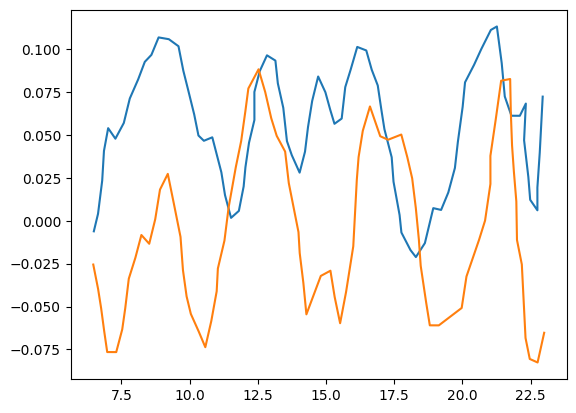

In [68]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values)
plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values)

In [69]:
# drop backwards times

ix_vx_drop = np.where(np.diff(df_raw_vx.time.values)<0)[0]
df_raw_vx = df_raw_vx.drop(ix_vx_drop)

ix_vy_drop = np.where(np.diff(df_raw_vy.time.values)<0)[0]
df_raw_vy = df_raw_vy.drop(ix_vy_drop)

In [70]:
from scipy.interpolate import UnivariateSpline

In [71]:
interp_timestamps_sec = np.arange(df_raw_vx.time.min(), df_raw_vx.time.max(), 0.1)

In [75]:
spline_x = UnivariateSpline(df_raw_vx.time, df_raw_vx.xvel, s=1e-3, k=3)  # s=smoothing amount
interp_vx = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_raw_vy.time, df_raw_vy.yvel, s=1e-3, k=3)  # s=smoothing amount
interp_vy = spline_y(interp_timestamps_sec)

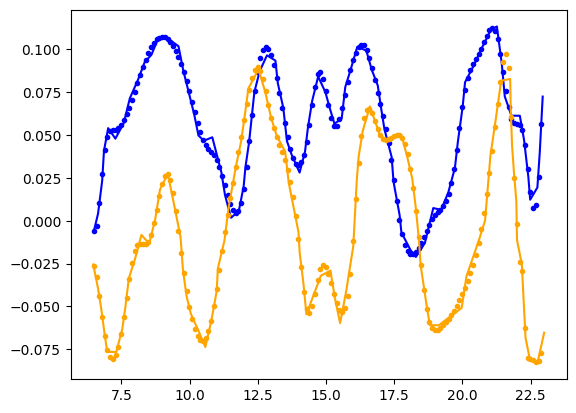

In [76]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values, color='blue')
plt.plot(interp_timestamps_sec, interp_vx, '.', color='blue')


plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values, color='orange')
plt.plot(interp_timestamps_sec, interp_vy, '.', color='orange')

In [77]:
dt = np.median(np.diff(interp_timestamps_sec))
x = np.cumsum(interp_vx*dt)
y = np.cumsum(interp_vy*dt)

In [78]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': x,
                                     'y': y,
                                     'xvel': interp_vx,
                                     'yvel': interp_vy})

8.489420720199993


Text(0, 0.5, 'y position, m (cross flow)')

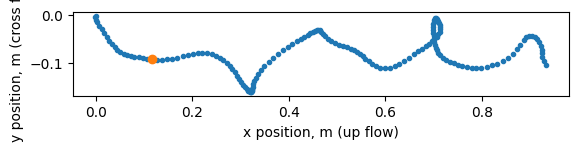

In [94]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

tix = 20
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

ax.set_xlabel('x position, m (up flow)')
ax.set_ylabel('y position, m (cross flow)')

In [80]:
import pynumdiff

In [81]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [82]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'shark_a'
df_calibrated_interp['obj_id_unique'] = 'shark_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

In [106]:
np.mean(np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2))

0.07932336493291399

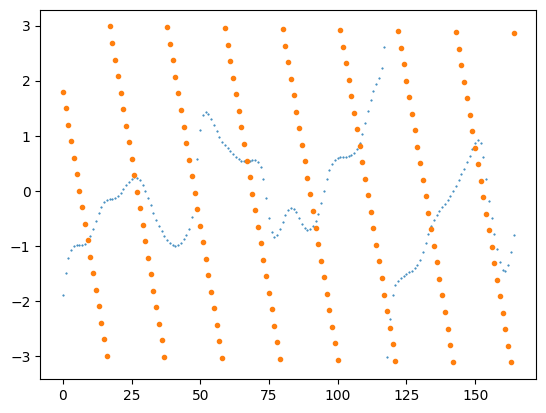

In [83]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.3
intercept=1.8
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [84]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [85]:
trajec = df_calibrated_interp

In [86]:
trajec.shape

(165, 11)

In [101]:
tix

20

In [87]:
course = trajec.course_smoothish.values
abs_min_ix = tix
abs_max_ix = 155
min_ix_range = 50
max_ix_range = 100

In [95]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 30, 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)

/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [96]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [97]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix
3,88,140,0.152155,-2.272724,1.301982,0.986441,0.707060,0.726767,0.071536,0.071536,0.966734,0.328838,0.010369,0.973420,0.050585,0.716779,0.254470,98
9,102,152,0.157948,-3.195836,1.359305,0.951958,0.727320,0.737219,0.046105,0.046105,0.942060,0.335711,-0.150101,0.949187,0.072605,0.764025,0.272761,140
6,92,142,0.153735,3.753618,1.272051,1.001537,0.701348,0.727352,0.084438,0.084438,0.975533,0.304525,-0.012784,0.961972,0.081748,0.700272,0.281176,99
5,97,152,0.147459,4.354852,1.291142,0.949862,0.689681,0.709504,0.069026,0.069026,0.930039,0.330627,-0.067413,0.940261,0.132016,0.726086,0.291263,99
7,74,154,0.123955,1.243257,1.710269,0.797604,0.583676,0.587811,-0.029452,-0.029452,0.793469,0.466736,-0.022998,0.928676,-0.081646,0.731787,0.334917,92
4,76,139,0.142757,-1.096753,1.607889,0.886065,0.551286,0.551747,-0.012407,-0.012407,0.885605,0.473606,0.022268,0.923002,0.091588,0.622173,0.382542,96
0,33,91,-0.054162,-2.323632,-2.257392,0.847897,0.115188,0.409620,0.359225,0.359225,0.553466,0.398437,-0.373237,0.537541,0.028103,0.135852,0.657417,74
1,44,121,0.124200,-5.616096,1.779813,0.798364,0.074436,0.105605,-0.146944,-0.146944,0.767195,0.693276,0.094627,0.883872,0.054951,0.093235,0.685577,46
8,41,136,-0.039075,-3.138842,-2.445581,0.620628,0.277498,0.479571,0.168831,0.168831,0.418555,0.356928,-0.066645,0.265975,0.097534,0.447125,1.086036,81
2,42,131,-0.030074,2.319818,-2.972100,1.019858,0.474826,1.004350,0.090620,0.090620,0.490334,-0.121515,0.068537,0.180244,0.088472,0.465580,1.087410,78


In [102]:
best_unifying_algo_fit = unifying_algo_fit.iloc[1]

In [103]:
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [104]:
import figurefirst as fifi

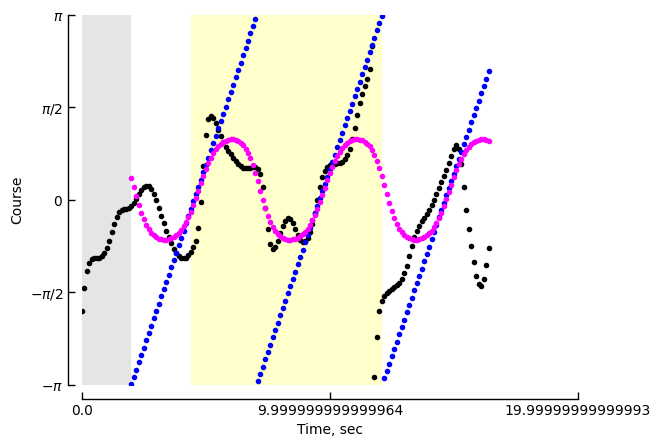

In [105]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])